In [1]:
import json
import re

# Open and read file 
with open('corpus.json', 'r', encoding='utf-8') as file:
    content = file.read()

# Remove control characters using regex
cleaned_content = re.sub(r'[\x00-\x1F\x7F-\x9F]', '', content)

try:
    data = json.loads(cleaned_content)
    print("JSON loaded successfully!")

except json.JSONDecodeError as e:
    print(f"Having trouble loading JSON: {e}")

    error_location = e.pos
    start = max(0, error_location - 50)
    end = min(len(cleaned_content), error_location + 50)
    print(f"Context around the error: '{cleaned_content[start:end]}'")

JSON loaded successfully!


# Sem stopwords

In [10]:
import json
import re
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from nltk.corpus import stopwords
import nltk
import numpy as np
from collections import Counter

# Baixar stopwords se necessário
nltk.download('stopwords')

# Lista de stopwords em português
stopwords_en = set(stopwords.words('english'))

# 1. Carregar e limpar JSON
with open('corpus.json', 'r', encoding='utf-8') as file:
    content = file.read()

cleaned_content = re.sub(r'[\x00-\x1F\x7F-\x9F]', '', content)

try:
    data = json.loads(cleaned_content)
    print("JSON loaded successfully!")
except json.JSONDecodeError as e:
    print(f"Erro ao carregar JSON: {e}")
    error_location = e.pos
    start = max(0, error_location - 50)
    end = min(len(cleaned_content), error_location + 50)
    print(f"Contexto do erro: '{cleaned_content[start:end]}'")


JSON loaded successfully!


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\rafae\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [11]:

# 2. Pré-processamento e remoção de stopwords
tokenized_articles = [article.get('artigo_tokenizado', []) for article in data]

# Remove stopwords
filtered_articles = [
    [token for token in tokens if token.lower() not in stopwords_en]
    for tokens in tokenized_articles
]

# Junta tokens em textos novamente
text_articles = [' '.join(tokens) for tokens in filtered_articles]

# 3. Análise de bigramas (N-Gramas)
bigram_vectorizer = CountVectorizer(ngram_range=(2, 2))
bigram_matrix = bigram_vectorizer.fit_transform(text_articles)
bigram_vocab = bigram_vectorizer.get_feature_names_out()

# Frequência dos bigramas
bigram_counts = bigram_matrix.toarray().sum(axis=0)
bigram_freq = list(zip(bigram_vocab, bigram_counts))
bigram_freq_sorted = sorted(bigram_freq, key=lambda x: x[1], reverse=True)

# 4. Estatísticas e visualização
print("\n=== Top 20 Bigramas mais frequentes (sem stopwords) ===")
for bigram, count in bigram_freq_sorted[:20]:
    print(f"{bigram}: {count}")



=== Top 20 Bigramas mais frequentes (sem stopwords) ===
language models: 225
large language: 202
et al: 174
natural language: 162
fine tuning: 158
style transfer: 140
universidade federal: 113
authorized licensed: 112
downloaded may: 112
federal piaui: 112
ieee xplore: 112
licensed use: 112
limited universidade: 112
may utc: 112
piaui downloaded: 112
restrictions apply: 112
use limited: 112
utc ieee: 112
xplore restrictions: 112
text style: 109


In [12]:

total_bigrams = sum(bigram_counts)
unique_bigrams = len(bigram_vocab)
mean_frequency = total_bigrams / unique_bigrams

print(f"\nTotal de bigramas: {total_bigrams}")
print(f"Número de bigramas únicos: {unique_bigrams}")
print(f"Frequência média: {mean_frequency:.2f}")



Total de bigramas: 66903
Número de bigramas únicos: 46850
Frequência média: 1.43


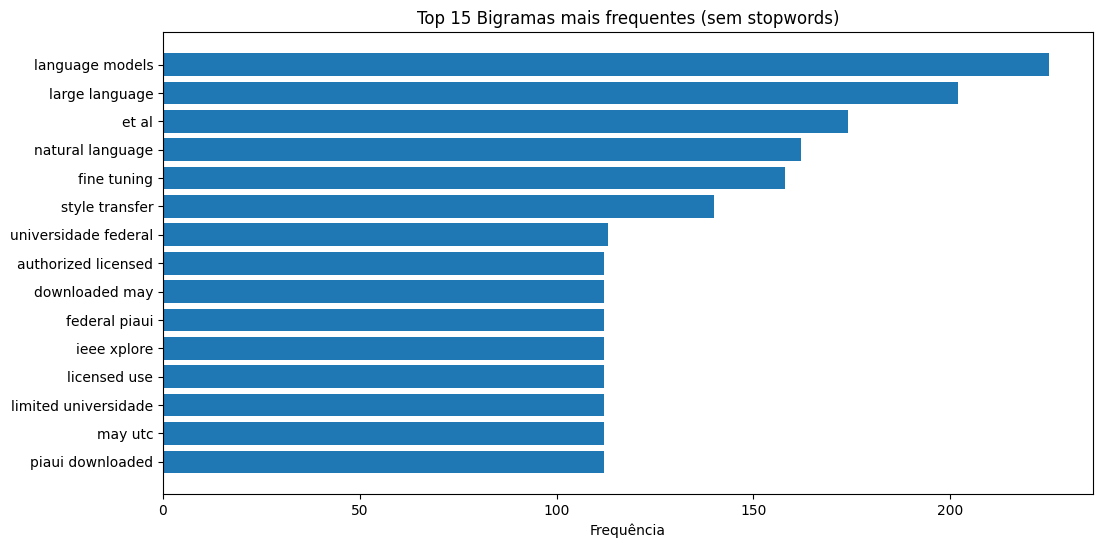

In [13]:

# Gráfico
top_n = 15
labels, values = zip(*bigram_freq_sorted[:top_n])
plt.figure(figsize=(12, 6))
plt.barh(labels[::-1], values[::-1])
plt.xlabel("Frequência")
plt.title("Top 15 Bigramas mais frequentes (sem stopwords)")
plt.show()


# Com stopwords

In [2]:
import json
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Supondo que 'data' já foi carregado anteriormente
tokenized_articles = [article.get('artigo_tokenizado', []) for article in data]
text_articles = [' '.join(tokens) for tokens in tokenized_articles]

In [3]:
from collections import Counter

# Exemplo com Bigramas
bigram_vectorizer = CountVectorizer(ngram_range=(2, 2))
bigram_matrix = bigram_vectorizer.fit_transform(text_articles)
bigram_vocab = bigram_vectorizer.get_feature_names_out()

# Frequência dos bigramas
bigram_counts = bigram_matrix.toarray().sum(axis=0)
bigram_freq = list(zip(bigram_vocab, bigram_counts))
bigram_freq_sorted = sorted(bigram_freq, key=lambda x: x[1], reverse=True)

print("\n=== Top 20 Bigramas mais frequentes ===")
for bigram, count in bigram_freq_sorted[:20]:
    print(f"{bigram}: {count}")



=== Top 20 Bigramas mais frequentes ===
of the: 737
in the: 437
to the: 268
the model: 234
language models: 225
for the: 221
large language: 202
on the: 193
with the: 189
and the: 185
et al: 174
such as: 166
natural language: 162
fine tuning: 158
is the: 150
from the: 144
based on: 143
style transfer: 140
by the: 121
the llm: 120


In [4]:
total_bigrams = sum(bigram_counts)
unique_bigrams = len(bigram_vocab)
mean_frequency = total_bigrams / unique_bigrams

print(f"\nTotal de bigramas: {total_bigrams}")
print(f"Número de bigramas únicos: {unique_bigrams}")
print(f"Frequência média: {mean_frequency:.2f}")



Total de bigramas: 99066
Número de bigramas únicos: 50889
Frequência média: 1.95


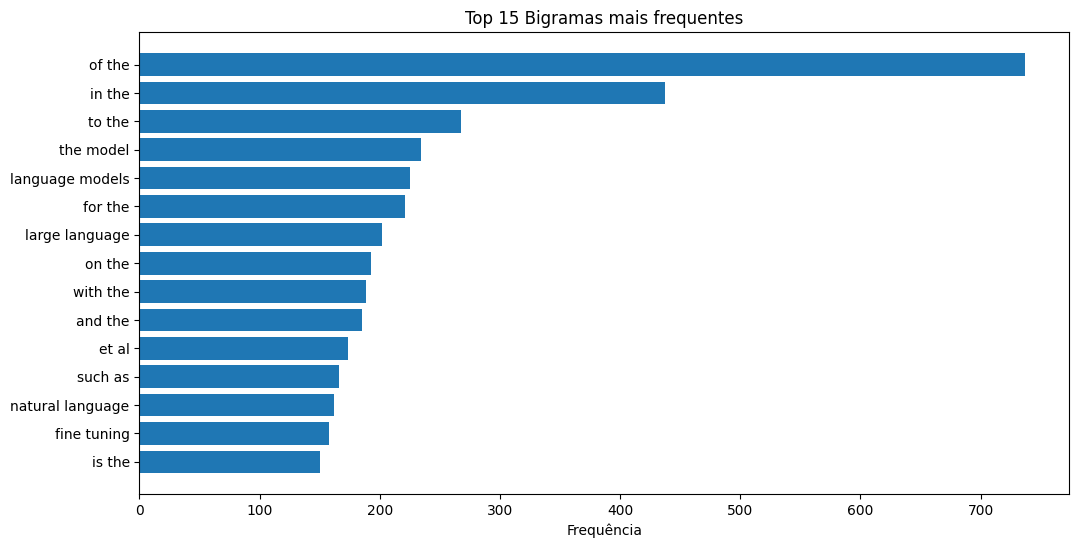

In [5]:
import matplotlib.pyplot as plt

top_n = 15
labels, values = zip(*bigram_freq_sorted[:top_n])
plt.figure(figsize=(12, 6))
plt.barh(labels[::-1], values[::-1])
plt.xlabel("Frequência")
plt.title("Top 15 Bigramas mais frequentes")
plt.show()
